# Harbor Task Solution EDA

Analysis covering:
1. `solution_grace/claude4.6_sonnet/harbor_tasks_8192/result.json` — eval results
2. `prepared_data/train_4.5opus-8192-task_4.6sonnet-sol_combined.parquet`
3. `prepared_data/train_4.5opus-4.6opus-task_4.6sonnet-sol_combined.parquet`

In [20]:
import json
import re
import collections
from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## Part 1 — Eval results (`harbor_tasks_8192/result.json`)

In [21]:
RESULT_PATH = Path('../solution_grace/claude4.6_sonnet/harbor_tasks_8192/result.json')

with open(RESULT_PATH) as f:
    result = json.load(f)

print('started_at :', result['started_at'])
print('finished_at:', result['finished_at'])
print('n_total_trials:', result['n_total_trials'])

started_at : 2026-07-07T22:55:43.922089
finished_at: 2026-07-14T00:28:57.810205
n_total_trials: 26480


In [22]:
stats = result['stats']
eval_key = list(stats['evals'].keys())[0]
ev = stats['evals'][eval_key]

n_trials    = ev['n_trials']
n_errors    = ev['n_errors']
mean_reward = ev['metrics'][0]['mean']

print(f'Eval key   : {eval_key}')
print(f'n_trials   : {n_trials:,}')
print(f'n_errors   : {n_errors:,}  ({100*n_errors/n_trials:.1f}%)')
print(f'mean reward: {mean_reward:.4f}')

Eval key   : aicore-terminus-2__harbor_tasks_8192
n_trials   : 24,905
n_errors   : 1,853  (7.4%)
mean reward: 0.5652


In [23]:
reward_stats = ev['reward_stats']['reward']

rows = []
for reward_val, trial_ids in reward_stats.items():
    r = float(reward_val)
    for tid in trial_ids:
        parts = tid.rsplit('__', 1)
        task_id = parts[0]
        attempt = parts[1] if len(parts) == 2 else ''
        rows.append({'trial_id': tid, 'task_id': task_id, 'attempt': attempt, 'reward': r})

df_trials = pd.DataFrame(rows)
print(f'Total scored trials : {len(df_trials):,}')
print(f'Unique tasks        : {df_trials["task_id"].nunique():,}')
print()
print(df_trials['reward'].value_counts().sort_index())

Total scored trials : 24,905
Unique tasks        : 3,302

reward
0.0     9939
1.0    14966
Name: count, dtype: int64


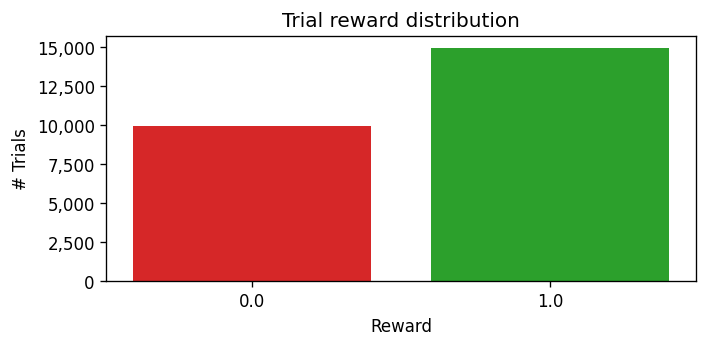

In [24]:
vc = df_trials['reward'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([str(v) for v in vc.index], vc.values,
       color=['#d62728' if v < 0.5 else '#2ca02c' for v in vc.index])
ax.set_xlabel('Reward')
ax.set_ylabel('# Trials')
ax.set_title('Trial reward distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [25]:
task_df = df_trials.groupby('task_id').agg(
    n_attempts=('reward', 'count'),
    n_pass=('reward', lambda x: (x == 1.0).sum()),
    pass_rate=('reward', 'mean'),
).reset_index()

task_df['pass_any'] = task_df['n_pass'] > 0

print(f'Tasks with ≥1 pass : {task_df["pass_any"].sum():,} / {len(task_df):,}  '
      f'({100*task_df["pass_any"].mean():.1f}%)')
print(f'Tasks all-fail     : {(task_df["n_pass"] == 0).sum():,}')
print(f'Tasks all-pass     : {(task_df["n_pass"] == task_df["n_attempts"]).sum():,}')

Tasks with ≥1 pass : 2,092 / 3,302  (63.4%)
Tasks all-fail     : 1,210
Tasks all-pass     : 1,832


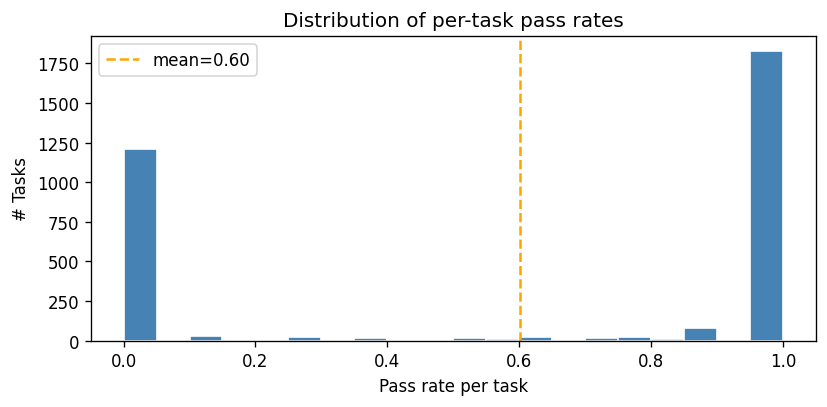

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(task_df['pass_rate'], bins=20, edgecolor='white', color='steelblue')
ax.axvline(task_df['pass_rate'].mean(), color='orange', linestyle='--',
           label=f'mean={task_df["pass_rate"].mean():.2f}')
ax.set_xlabel('Pass rate per task')
ax.set_ylabel('# Tasks')
ax.set_title('Distribution of per-task pass rates')
ax.legend()
plt.tight_layout()
plt.show()

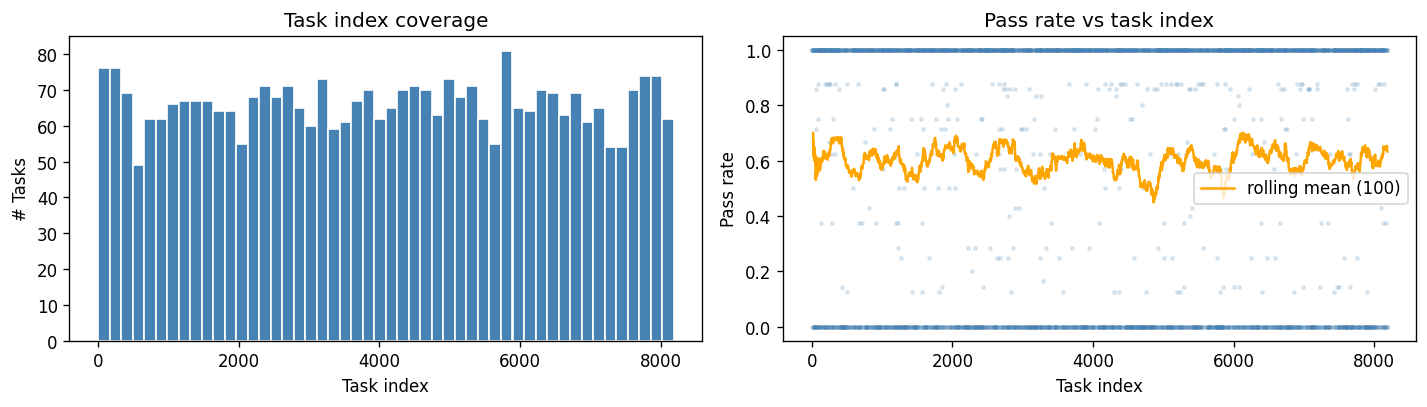

Task index range: 0 – 8186


In [27]:
task_df['task_num'] = task_df['task_id'].str.extract(r'task_(\d+)_').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(task_df['task_num'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Task index'); axes[0].set_ylabel('# Tasks')
axes[0].set_title('Task index coverage')

sorted_df = task_df.sort_values('task_num')
axes[1].scatter(task_df['task_num'], task_df['pass_rate'], alpha=0.15, s=4, color='steelblue')
rolling = sorted_df.set_index('task_num')['pass_rate'].rolling(100, min_periods=10).mean()
axes[1].plot(rolling.index, rolling.values, color='orange', linewidth=1.5, label='rolling mean (100)')
axes[1].set_xlabel('Task index'); axes[1].set_ylabel('Pass rate')
axes[1].set_title('Pass rate vs task index')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Task index range: {task_df["task_num"].min()} – {task_df["task_num"].max()}')

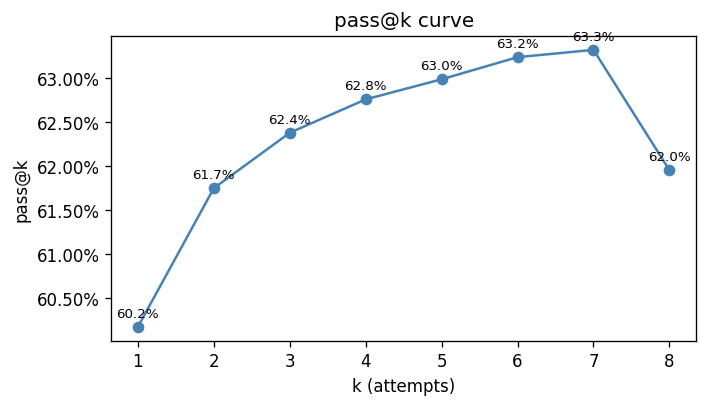

In [28]:
def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

max_k = int(task_df['n_attempts'].max())
ks = list(range(1, max_k + 1))
passk_vals = [
    task_df[task_df['n_attempts'] >= k]
    .apply(lambda r: pass_at_k(int(r['n_attempts']), int(r['n_pass']), k), axis=1)
    .mean()
    for k in ks
]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks, passk_vals, marker='o', color='steelblue')
ax.set_xlabel('k (attempts)'); ax.set_ylabel('pass@k')
ax.set_title('pass@k curve')
ax.set_xticks(ks)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for k, v in zip(ks, passk_vals):
    ax.annotate(f'{v:.1%}', (k, v), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Part 2 — Training parquet EDA

Comparing:
- **df1** (`train_4.5opus-8192-task_4.6sonnet-sol_combined`) — 1,882 rows
- **df2** (`train_4.5opus-4.6opus-task_4.6sonnet-sol_combined`) — 1,020 rows

In [29]:
PREPARED = Path('../prepared_data')

df1 = pd.read_parquet(PREPARED / 'train_4.5opus-8192-task_4.6sonnet-sol_combined.parquet')
df2 = pd.read_parquet(PREPARED / 'train_4.5opus-4.6opus-task_4.6sonnet-sol_combined.parquet')

# Derived columns
for df in (df1, df2):
    df['desc_len']   = df['description'].str.len()
    df['task_num']   = df['task_dir'].str.extract(r'task_0*(\d+)_').astype(int)
    df['gt_corpus']  = df['reward_spec'].apply(lambda x: x['ground_truth']).str.extract(r'harbor_tasks/([^/]+)/')

print('df1 shape:', df1.shape)
print('df2 shape:', df2.shape)

df1 shape: (1882, 10)
df2 shape: (1020, 10)


### Overlap & uniqueness

In [30]:
td1, td2 = set(df1['task_dir']), set(df2['task_dir'])
desc1, desc2 = set(df1['description']), set(df2['description'])

print('=== task_dir overlap ===')
print(f'  df1 unique tasks : {len(td1):,}')
print(f'  df2 unique tasks : {len(td2):,}')
print(f'  shared           : {len(td1 & td2):,}  ← completely disjoint task sets')

print()
print('=== description overlap ===')
print(f'  shared descriptions  : {len(desc1 & desc2)}  (simple canonical tasks)')
print(f'  only in df1 (8192)   : {len(desc1 - desc2):,}')
print(f'  only in df2 (4.6opus): {len(desc2 - desc1):,}')

print()
shared = list(desc1 & desc2)
print('Shared description examples (first 100 chars):')
for d in shared:
    print(f'  • {d[:100]}')

=== task_dir overlap ===
  df1 unique tasks : 1,882
  df2 unique tasks : 1,020
  shared           : 0  ← completely disjoint task sets

=== description overlap ===
  shared descriptions  : 8  (simple canonical tasks)
  only in df1 (8192)   : 1,866
  only in df2 (4.6opus): 1,009

Shared description examples (first 100 chars):
  • I need a quick disk usage summary for everything under /home/user/experiments — just the top-level s
  • I need a jq command wrapped in a small script at /home/user/check_uptime.sh that reads /home/user/se
  • I need a symlink at /home/user/services/current that points to /home/user/services/v2.4.1 — the old 
  • I need to pull out just the IP addresses from /home/user/logs/access.log — one per line, deduplicate
  • I have a CSV at /home/user/data/employees.csv and I need it converted to JSON — just a straight arra
  • I need to add a French translation entry to our app's locale file at /home/user/app/locales/fr.json.
  • I need to rename the branch `dev-featur

### Source corpus breakdown

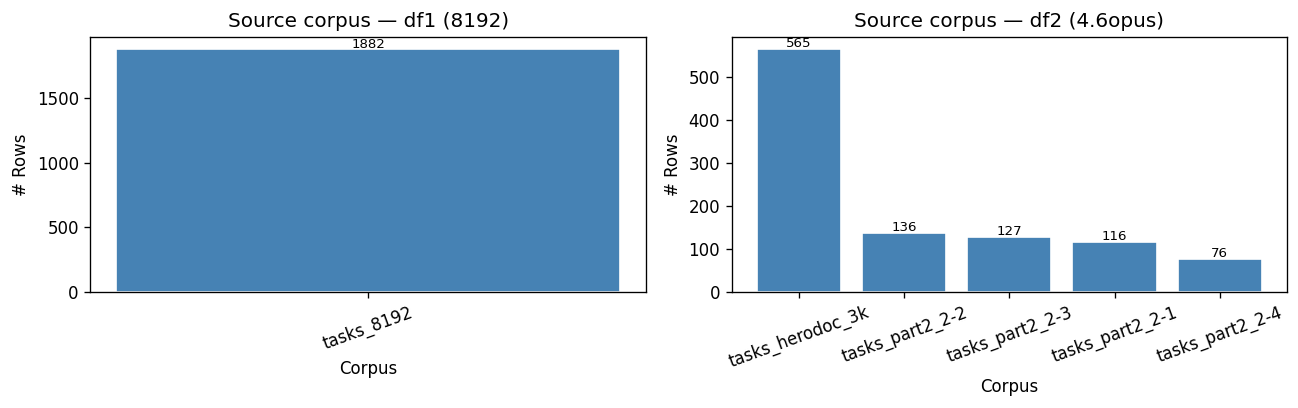

df2 corpus breakdown:
gt_corpus
tasks_herodoc_3k    565
tasks_part2_2-1     116
tasks_part2_2-2     136
tasks_part2_2-3     127
tasks_part2_2-4      76


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, df, label in [
    (axes[0], df1, 'df1 (8192)'),
    (axes[1], df2, 'df2 (4.6opus)'),
]:
    vc = df['gt_corpus'].value_counts()
    ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Source corpus — {label}')
    ax.set_xlabel('Corpus')
    ax.set_ylabel('# Rows')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('df2 corpus breakdown:')
print(df2.groupby('gt_corpus').size().to_string())

### Description length distribution

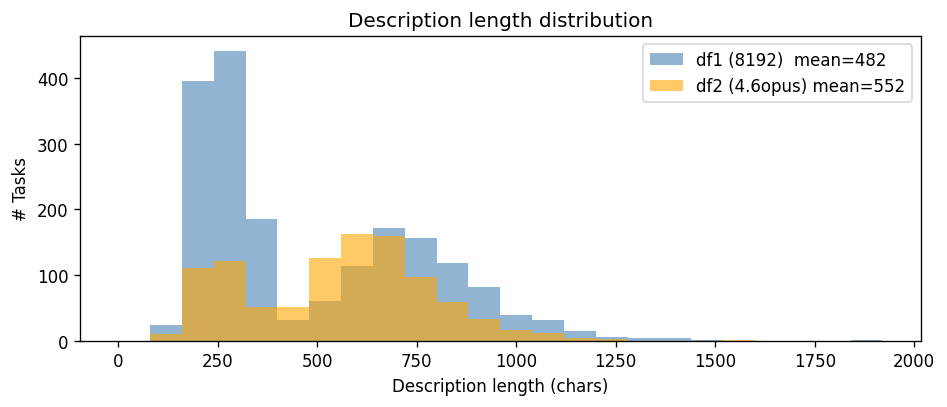

df1 desc_len: {'count': 1882.0, 'mean': 482.0, 'std': 279.0, 'min': 110.0, '25%': 248.0, '50%': 345.0, '75%': 712.0, 'max': 1854.0}
df2 desc_len: {'count': 1020.0, 'mean': 552.0, 'std': 231.0, 'min': 142.0, '25%': 329.0, '50%': 578.0, '75%': 702.0, 'max': 1526.0}


In [32]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = range(0, 2000, 80)
ax.hist(df1['desc_len'], bins=bins, alpha=0.6, label=f'df1 (8192)  mean={df1["desc_len"].mean():.0f}', color='steelblue')
ax.hist(df2['desc_len'], bins=bins, alpha=0.6, label=f'df2 (4.6opus) mean={df2["desc_len"].mean():.0f}', color='orange')
ax.set_xlabel('Description length (chars)')
ax.set_ylabel('# Tasks')
ax.set_title('Description length distribution')
ax.legend()
plt.tight_layout()
plt.show()

print('df1 desc_len:', df1['desc_len'].describe().round(0).to_dict())
print('df2 desc_len:', df2['desc_len'].describe().round(0).to_dict())

#### df2: description length by sub-corpus

`tasks_herodoc_3k` is bimodal/wide; `tasks_part2_*` are tighter and longer.

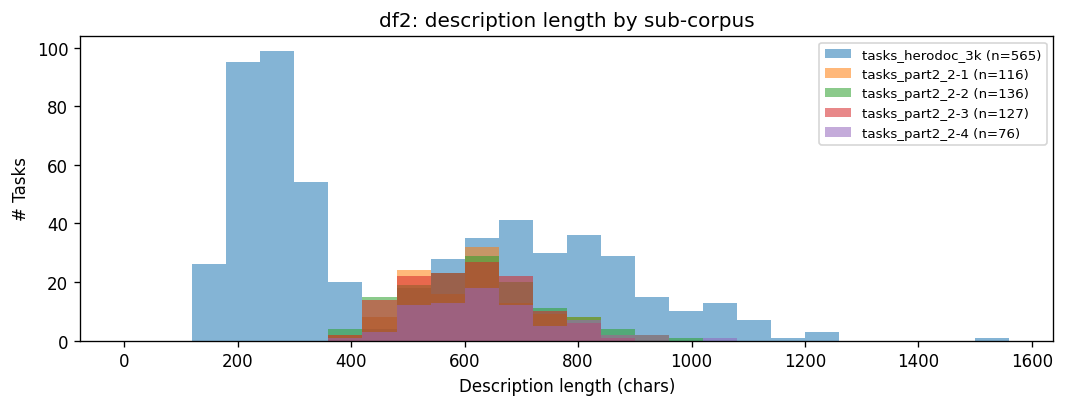

In [33]:
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = plt.cm.tab10.colors
for i, (corpus, grp) in enumerate(df2.groupby('gt_corpus')):
    ax.hist(grp['desc_len'], bins=range(0, 1600, 60), alpha=0.55,
            label=f'{corpus} (n={len(grp)})', color=colors[i])
ax.set_xlabel('Description length (chars)')
ax.set_ylabel('# Tasks')
ax.set_title('df2: description length by sub-corpus')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Task index coverage

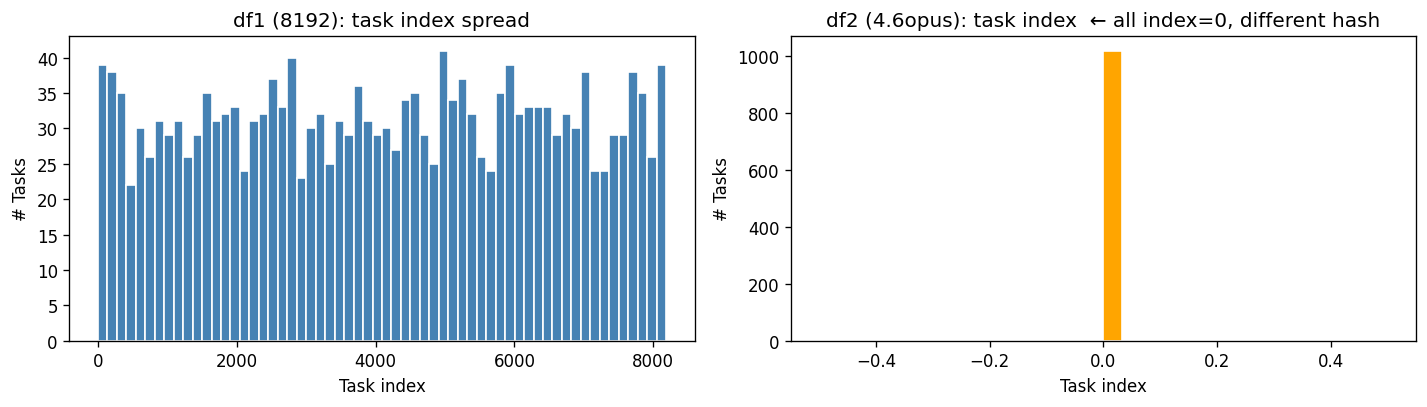

df1 task_num range: 0 – 8184
df2 task_num range: 0 – 0  (all 0 — tasks identified by hash, not sequential index)


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(df1['task_num'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('df1 (8192): task index spread')
axes[0].set_xlabel('Task index')
axes[0].set_ylabel('# Tasks')

axes[1].hist(df2['task_num'], bins=30, color='orange', edgecolor='white')
axes[1].set_title('df2 (4.6opus): task index  ← all index=0, different hash')
axes[1].set_xlabel('Task index')
axes[1].set_ylabel('# Tasks')

plt.tight_layout()
plt.show()

print(f'df1 task_num range: {df1["task_num"].min()} – {df1["task_num"].max()}')
print(f'df2 task_num range: {df2["task_num"].min()} – {df2["task_num"].max()}  '
      f'(all 0 — tasks identified by hash, not sequential index)')

### Vocabulary / keyword fingerprint

Top words exclusive to each dataset reveal their stylistic differences.

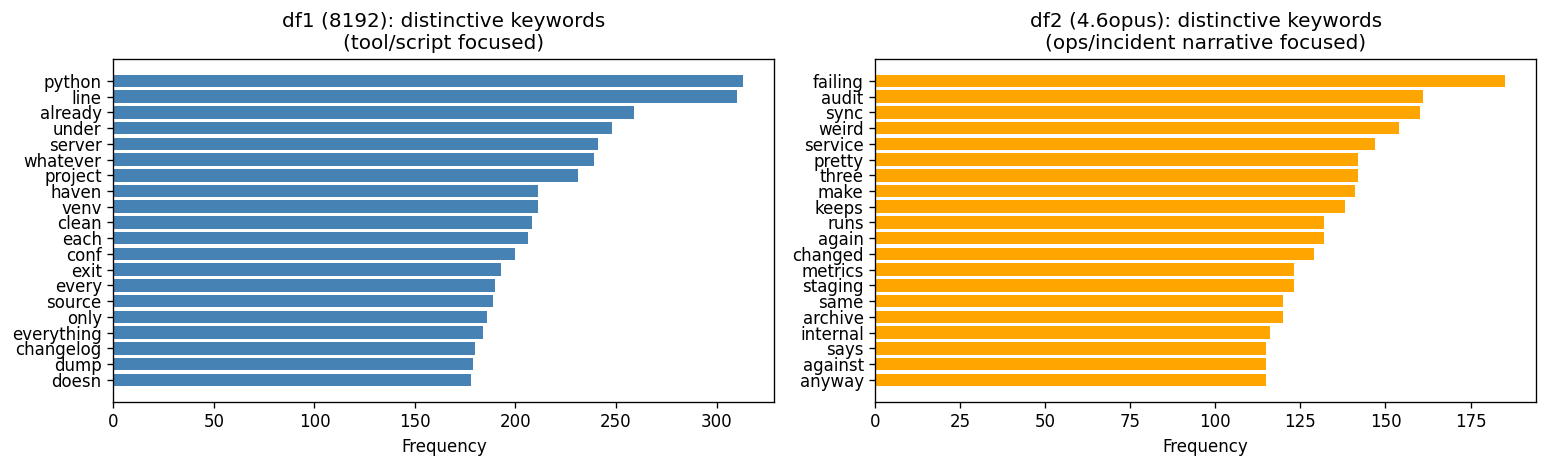

In [35]:
def word_freq(series, n=80):
    ctr = collections.Counter()
    for desc in series:
        for w in re.findall(r'[a-z]{4,}', desc.lower()):
            ctr[w] += 1
    return ctr

wf1 = word_freq(df1['description'])
wf2 = word_freq(df2['description'])
top1, top2 = set(w for w,_ in wf1.most_common(80)), set(w for w,_ in wf2.most_common(80))

unique_to_1 = [(w, c) for w, c in wf1.most_common(120) if w not in top2][:20]
unique_to_2 = [(w, c) for w, c in wf2.most_common(120) if w not in top1][:20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

words1, counts1 = zip(*unique_to_1)
axes[0].barh(words1[::-1], counts1[::-1], color='steelblue')
axes[0].set_title('df1 (8192): distinctive keywords\n(tool/script focused)')
axes[0].set_xlabel('Frequency')

words2, counts2 = zip(*unique_to_2)
axes[1].barh(words2[::-1], counts2[::-1], color='orange')
axes[1].set_title('df2 (4.6opus): distinctive keywords\n(ops/incident narrative focused)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### Summary comparison

In [36]:
summary = pd.DataFrame({
    'df1 (8192)': [
        len(df1),
        df1['gt_corpus'].nunique(),
        df1['gt_corpus'].value_counts().index[0],
        f"{df1['task_num'].min()}–{df1['task_num'].max()}",
        f"{df1['desc_len'].mean():.0f} (med {df1['desc_len'].median():.0f})",
        df1['description'].duplicated().sum(),
    ],
    'df2 (4.6opus)': [
        len(df2),
        df2['gt_corpus'].nunique(),
        ', '.join(df2['gt_corpus'].value_counts().index[:2]),
        f"{df2['task_num'].min()}–{df2['task_num'].max()} (all 0, hash-keyed)",
        f"{df2['desc_len'].mean():.0f} (med {df2['desc_len'].median():.0f})",
        df2['description'].duplicated().sum(),
    ],
}, index=['# rows', '# source corpora', 'primary corpus', 'task index range',
          'desc len mean (median)', 'duplicate descriptions'])

display(summary)

,df1 (8192),df2 (4.6opus)
# rows,1882,1020
# source corpora,1,5
primary corpus,tasks_8192,"tasks_herodoc_3k, tasks_part2_2-2"
task index range,0–8184,"0–0 (all 0, hash-keyed)"
desc len mean (median),482 (med 345),552 (med 578)
duplicate descriptions,8,3


---
## Part 3 — Task difficulty, category, test coverage & complexity

> df1 (8192) has local task files (`task.toml` + tests); df2 task files are not available locally so we derive complexity signals from description text alone.

In [37]:
TASK_ROOT = Path('../harbor_tasks_8192')

def parse_toml_simple(text):
    result, section = {}, {}
    result['_root'] = section
    for line in text.splitlines():
        line = line.strip()
        if line.startswith('[') and not line.startswith('[['):
            key = line.strip('[]').strip()
            section = {}
            result[key] = section
        elif '=' in line and not line.startswith('#'):
            k, _, v = line.partition('=')
            section[k.strip()] = v.strip().strip('"')
    return result

def extract_task_meta(task_dir_name):
    td = TASK_ROOT / task_dir_name
    if not td.exists():
        return {}
    toml_path = td / 'task.toml'
    if not toml_path.exists():
        return {}
    toml = parse_toml_simple(toml_path.read_text())
    meta = toml.get('metadata', {})
    tests_dir = td / 'tests'
    n_fns = n_classes = n_files = 0
    if tests_dir.exists():
        py_files = list(tests_dir.glob('*.py'))
        n_files = len(py_files)
        for f in py_files:
            txt = f.read_text()
            n_fns    += len(re.findall(r'^\s*def test_',   txt, re.MULTILINE))
            n_classes += len(re.findall(r'^\s*class Test', txt, re.MULTILINE))
    return {
        'difficulty':     meta.get('difficulty', 'unknown'),
        'category':       meta.get('category',   'unknown'),
        'n_test_files':   n_files,
        'n_test_fns':     n_fns,
        'n_test_classes': n_classes,
    }

print("Extracting df1 task metadata from disk...")
meta1 = df1['task_dir'].apply(extract_task_meta).apply(pd.Series)
df1 = pd.concat([df1.reset_index(drop=True), meta1], axis=1)
print(f"Resolved: {(df1['difficulty'] != '').sum()} / {len(df1)}")
print(df1['difficulty'].value_counts())

Extracting df1 task metadata from disk...
Resolved: 1882 / 1882
difficulty
easy      1076
medium     681
hard       125
Name: count, dtype: int64


In [38]:
# Also merge eval pass-rate into df1
task_pass = df_trials.groupby('task_id').agg(
    n_attempts=('reward', 'count'),
    n_pass=('reward', lambda x: (x == 1.0).sum()),
    pass_rate=('reward', 'mean'),
).reset_index().rename(columns={'task_id': 'task_dir'})

df1 = df1.merge(task_pass, on='task_dir', how='left')
print(f"df1 with pass_rate merged: {df1['pass_rate'].notna().sum()} / {len(df1)} rows have eval data")

df1 with pass_rate merged: 1882 / 1882 rows have eval data


### Difficulty breakdown — df1 (8192)

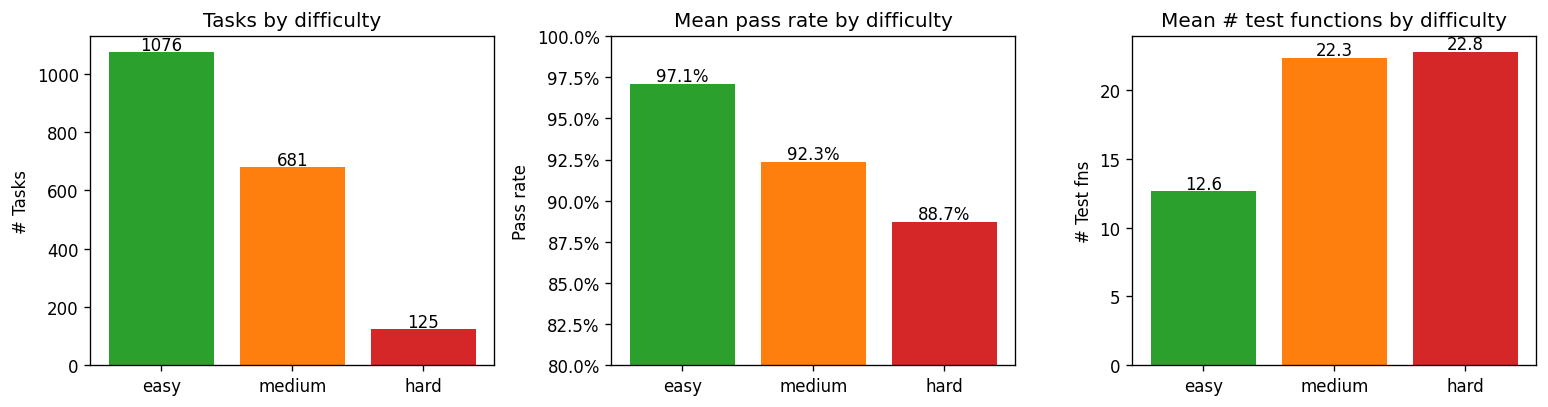

,n,avg_desc_len,avg_n_test_fns,avg_n_test_classes,avg_pass_rate,pct_all_fail
difficulty,,,,,,
easy,1076,265.12,12.64,2.44,0.97,0.0
hard,125,1007.27,22.78,6.63,0.89,0.0
medium,681,727.91,22.31,6.26,0.92,0.0


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
diff_order = ['easy', 'medium', 'hard']
colors_diff = {'easy': '#2ca02c', 'medium': '#ff7f0e', 'hard': '#d62728'}

# Count
vc_diff = df1['difficulty'].value_counts().reindex(diff_order)
axes[0].bar(vc_diff.index, vc_diff.values, color=[colors_diff[d] for d in vc_diff.index])
axes[0].set_title('Tasks by difficulty')
axes[0].set_ylabel('# Tasks')
for i, v in enumerate(vc_diff.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Pass rate by difficulty
pr_diff = df1.groupby('difficulty')['pass_rate'].mean().reindex(diff_order)
axes[1].bar(pr_diff.index, pr_diff.values, color=[colors_diff[d] for d in pr_diff.index])
axes[1].set_title('Mean pass rate by difficulty')
axes[1].set_ylabel('Pass rate')
axes[1].set_ylim(0.8, 1.0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate(pr_diff.values):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center')

# n_test_fns by difficulty
nt_diff = df1.groupby('difficulty')['n_test_fns'].mean().reindex(diff_order)
axes[2].bar(nt_diff.index, nt_diff.values, color=[colors_diff[d] for d in nt_diff.index])
axes[2].set_title('Mean # test functions by difficulty')
axes[2].set_ylabel('# Test fns')
for i, v in enumerate(nt_diff.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

display(df1.groupby('difficulty').agg(
    n=('task_dir','count'),
    avg_desc_len=('desc_len','mean'),
    avg_n_test_fns=('n_test_fns','mean'),
    avg_n_test_classes=('n_test_classes','mean'),
    avg_pass_rate=('pass_rate','mean'),
    pct_all_fail=('n_pass', lambda x: (x == 0).mean()),
).round(2))

### Test coverage distribution by difficulty

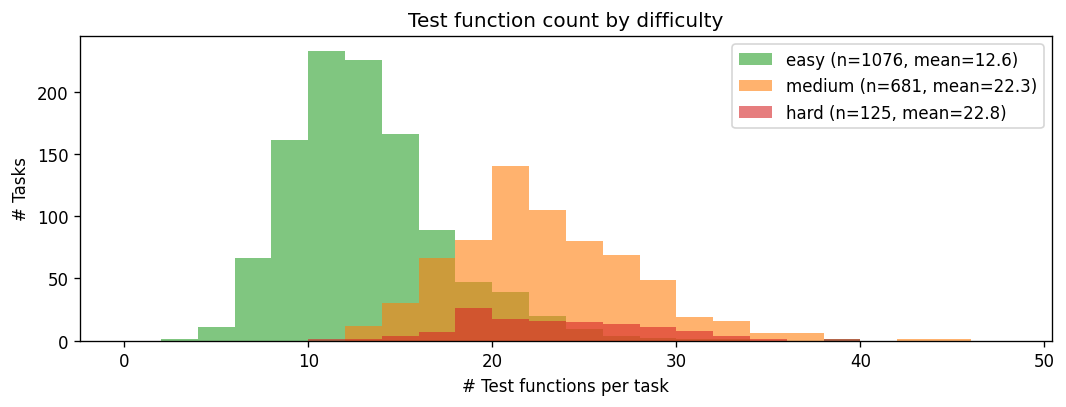

In [40]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for diff in diff_order:
    sub = df1[df1['difficulty'] == diff]['n_test_fns']
    ax.hist(sub, bins=range(0, 50, 2), alpha=0.6,
            label=f'{diff} (n={len(sub)}, mean={sub.mean():.1f})',
            color=colors_diff[diff])
ax.set_xlabel('# Test functions per task')
ax.set_ylabel('# Tasks')
ax.set_title('Test function count by difficulty')
ax.legend()
plt.tight_layout()
plt.show()

### Category analysis — df1 (8192)

In [41]:
def broad_cat(cat):
    c = cat.lower()
    if any(k in c for k in ['version', 'changelog', 'git', 'branch', 'commit', 'patch', 'submodule', 'diff']): return 'version_control'
    if any(k in c for k in ['web', 'http', 'server', 'port', 'nginx', 'flask', 'api', 'webserver']): return 'web_services'
    if any(k in c for k in ['file', 'directory', 'symlink', 'compress', 'backup', 'archiv', 'checksum', 'encoding']): return 'filesystem'
    if any(k in c for k in ['database', 'sql', 'sqlite', 'redis', 'mongo']): return 'database'
    if any(k in c for k in ['python', 'pip', 'venv', 'package', 'environment', 'virtual']): return 'python_env'
    if any(k in c for k in ['network', 'firewall', 'dns', 'ssh', 'sync', 'remote', 'rsync']): return 'networking'
    if any(k in c for k in ['pipeline', 'data', 'transform', 'csv', 'json', 'yaml', 'parse', 'jq', 'column', 'log filter']): return 'data_processing'
    if any(k in c for k in ['service', 'daemon', 'systemd', 'docker', 'container', 'deploy', 'cron', 'timer']): return 'services_infra'
    if any(k in c for k in ['performance', 'optim', 'profil', 'benchmark']): return 'performance'
    if any(k in c for k in ['debug', 'diagnos', 'old code', 'legacy', 'exploit', 'security', 'vulnerab']): return 'debugging_security'
    if any(k in c for k in ['makefile', 'build', 'automat', 'markdown', 'document']): return 'build_docs'
    return 'other'

df1['broad_cat'] = df1['category'].apply(broad_cat)

cat_stats = df1.groupby('broad_cat').agg(
    n=('task_dir', 'count'),
    pass_rate=('pass_rate', 'mean'),
    avg_tests=('n_test_fns', 'mean'),
    avg_desc_len=('desc_len', 'mean'),
    pct_hard=('difficulty', lambda x: (x == 'hard').mean()),
    pct_medium=('difficulty', lambda x: (x == 'medium').mean()),
).sort_values('n', ascending=False).round(2)

display(cat_stats)

,n,pass_rate,avg_tests,avg_desc_len,pct_hard,pct_medium
broad_cat,,,,,,
filesystem,323,0.94,17.00,543.20,0.10,0.42
other,277,0.97,16.86,516.35,0.06,0.45
python_env,274,0.96,16.06,420.27,0.05,0.32
version_control,206,0.92,17.86,492.58,0.07,0.34
debugging_security,153,0.95,16.57,452.35,0.04,0.34
data_processing,146,0.94,16.85,449.66,0.08,0.25
networking,115,0.95,16.43,452.90,0.07,0.30
web_services,107,0.93,15.67,464.93,0.13,0.30
database,96,0.96,17.42,482.67,0.03,0.36


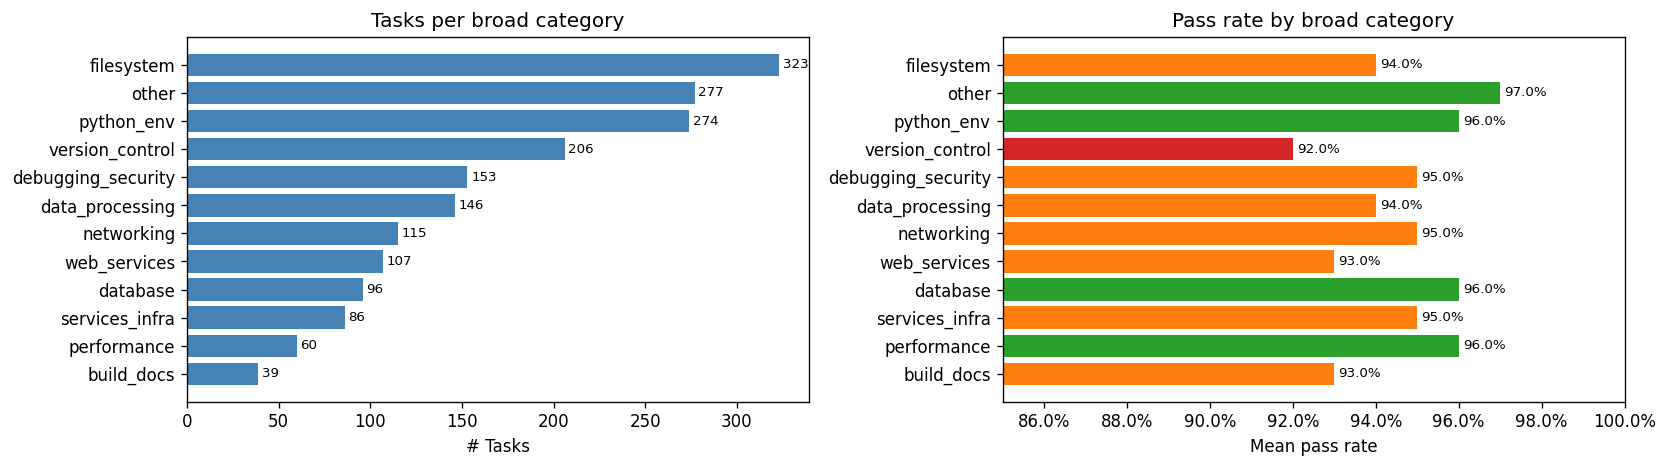

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cats_ordered = cat_stats.sort_values('n').index
n_vals = cat_stats.loc[cats_ordered, 'n']
pr_vals = cat_stats.loc[cats_ordered, 'pass_rate']

axes[0].barh(cats_ordered, n_vals, color='steelblue')
axes[0].set_xlabel('# Tasks')
axes[0].set_title('Tasks per broad category')
for i, v in enumerate(n_vals):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=8)

bar_colors = ['#d62728' if v < 0.93 else '#ff7f0e' if v < 0.96 else '#2ca02c' for v in pr_vals]
axes[1].barh(cats_ordered, pr_vals, color=bar_colors)
axes[1].set_xlabel('Mean pass rate')
axes[1].set_title('Pass rate by broad category')
axes[1].set_xlim(0.85, 1.0)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate(pr_vals):
    axes[1].text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

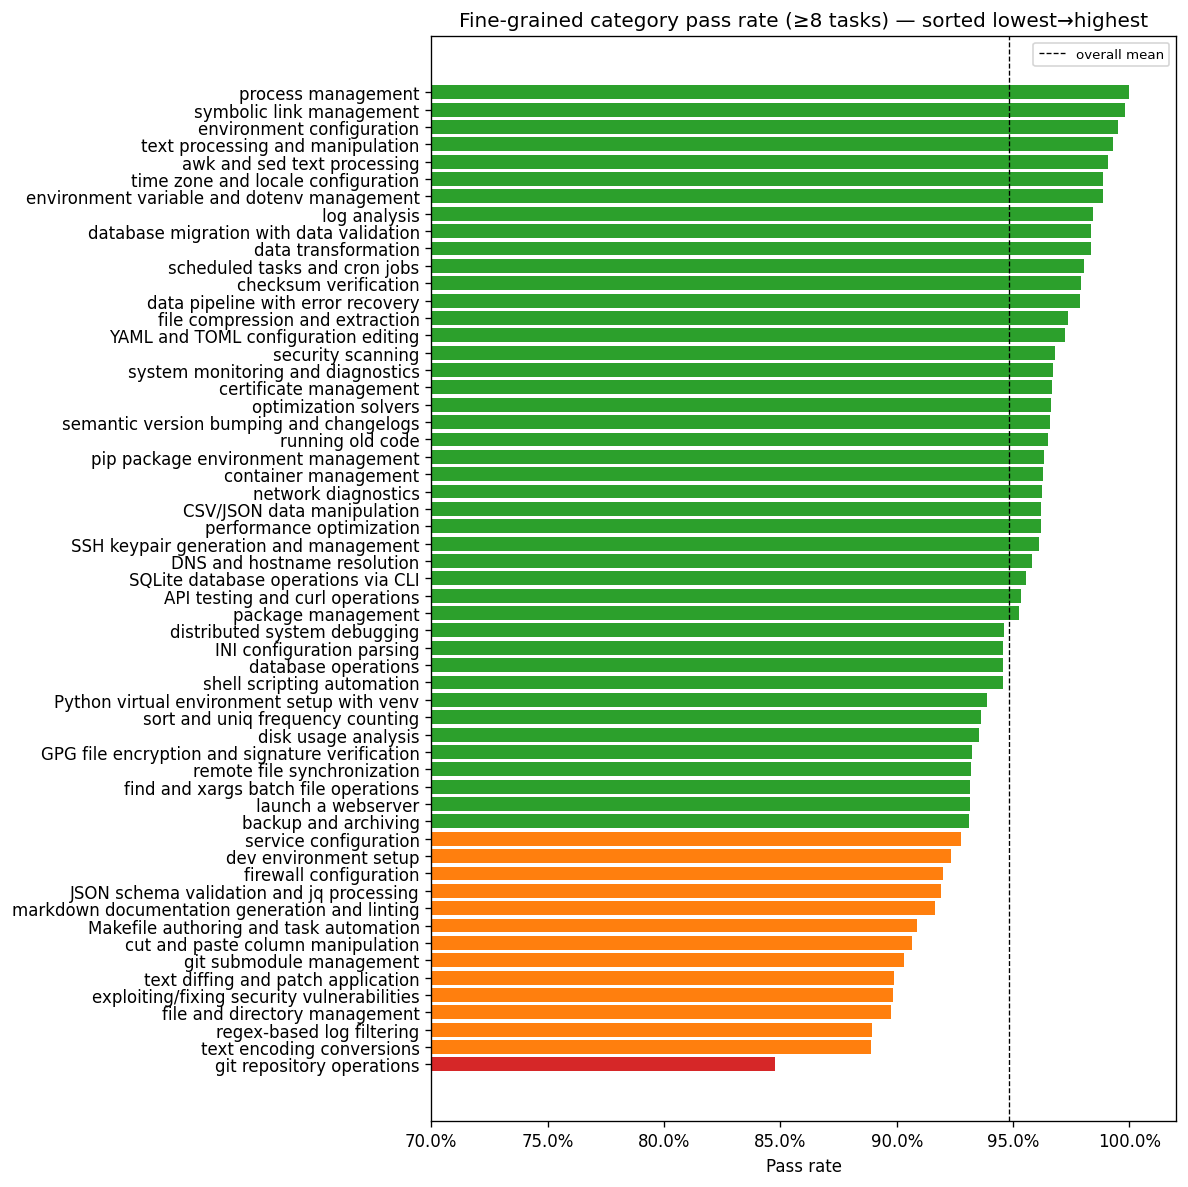


Bottom 10 (hardest categories):


,n,pass_rate,avg_tests,difficulty
category,,,,
git repository operations,26,0.85,17.54,medium
text encoding conversions,9,0.89,17.22,easy
regex-based log filtering,16,0.89,18.06,easy
file and directory management,47,0.90,16.87,medium
exploiting/fixing security vulnerabilities,20,0.90,18.50,medium
text diffing and patch application,58,0.90,17.55,easy
git submodule management,30,0.90,14.27,easy
cut and paste column manipulation,22,0.91,17.55,easy
Makefile authoring and task automation,34,0.91,18.56,medium


In [43]:
# Top 30 fine-grained categories by pass rate (min 8 tasks)
fine_cat = df1.groupby('category').agg(
    n=('task_dir', 'count'),
    pass_rate=('pass_rate', 'mean'),
    avg_tests=('n_test_fns', 'mean'),
    difficulty=('difficulty', lambda x: x.mode()[0]),
).query('n >= 8').sort_values('pass_rate')

fig, ax = plt.subplots(figsize=(10, 10))
colors_cat = ['#d62728' if v < 0.88 else '#ff7f0e' if v < 0.93 else '#2ca02c'
              for v in fine_cat['pass_rate']]
ax.barh(fine_cat.index, fine_cat['pass_rate'], color=colors_cat)
ax.set_xlabel('Pass rate')
ax.set_title('Fine-grained category pass rate (≥8 tasks) — sorted lowest→highest')
ax.set_xlim(0.7, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(df1['pass_rate'].mean(), color='black', linestyle='--', linewidth=0.8, label='overall mean')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nBottom 10 (hardest categories):")
display(fine_cat.head(10)[['n', 'pass_rate', 'avg_tests', 'difficulty']].round(2))

### Passing status — df1 (8192)

Triaging tasks into: always-pass, mostly-pass, flaky, mostly-fail, always-fail.

pass_bucket
always_pass    1638
mostly_pass     102
flaky           115
mostly_fail      27
always_fail       0
Name: count, dtype: int64

Total tasks with eval data: 1882


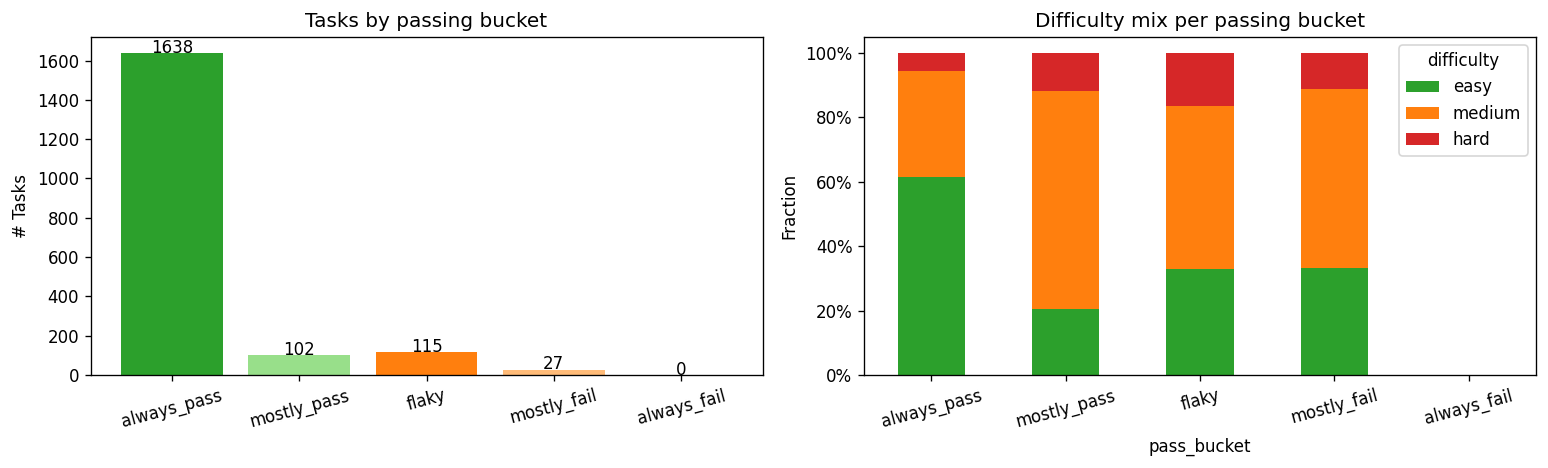

In [44]:
def pass_bucket(row):
    if row['n_pass'] == row['n_attempts']:         return 'always_pass'
    elif row['pass_rate'] >= 0.75:                 return 'mostly_pass'
    elif row['pass_rate'] >= 0.25:                 return 'flaky'
    elif row['pass_rate'] > 0:                     return 'mostly_fail'
    else:                                          return 'always_fail'

df1_eval = df1[df1['pass_rate'].notna()].copy()
df1_eval['pass_bucket'] = df1_eval.apply(pass_bucket, axis=1)

bucket_order = ['always_pass', 'mostly_pass', 'flaky', 'mostly_fail', 'always_fail']
bucket_colors = {'always_pass': '#2ca02c', 'mostly_pass': '#98df8a',
                 'flaky': '#ff7f0e', 'mostly_fail': '#ffbb78', 'always_fail': '#d62728'}

vc_bucket = df1_eval['pass_bucket'].value_counts().reindex(bucket_order).fillna(0).astype(int)
print(vc_bucket)
print(f"\nTotal tasks with eval data: {len(df1_eval)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(vc_bucket.index, vc_bucket.values,
            color=[bucket_colors[b] for b in vc_bucket.index])
axes[0].set_title('Tasks by passing bucket')
axes[0].set_ylabel('# Tasks')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(vc_bucket.values):
    axes[0].text(i, v + 2, str(v), ha='center')

# Difficulty composition per bucket
bucket_diff = df1_eval.groupby(['pass_bucket', 'difficulty']).size().unstack(fill_value=0).reindex(bucket_order)
bucket_diff_pct = bucket_diff.div(bucket_diff.sum(axis=1), axis=0)
bucket_diff_pct[diff_order].plot(kind='bar', ax=axes[1], stacked=True,
    color=[colors_diff[d] for d in diff_order])
axes[1].set_title('Difficulty mix per passing bucket')
axes[1].set_ylabel('Fraction')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='difficulty', bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### Semantic complexity & ambiguity signals

Derived from description text: bug mentions, debugging language, multi-step reasoning cues, ambiguity hedges, and question count.

In [45]:
def complexity_signals(desc):
    d = desc.lower()
    return {
        'has_bug':        bool(re.search(r'\b(bug|broken|wrong|incorrect|fails|failing|crash|error)\b', d)),
        'has_debug':      bool(re.search(r'\b(debug|diagnose|investigate|figure out)\b', d)),
        'has_multi_step': bool(re.search(r'\b(then|after|also|additionally|finally|step)\b', d)),
        'has_service':    bool(re.search(r'\b(service|server|daemon|deploy|container|docker)\b', d)),
        'has_ambiguity':  bool(re.search(r'\b(somehow|weird|strange|not sure|unclear|seems|might|probably|maybe)\b', d)),
        'has_constraint': bool(re.search(r'\b(must|should|only|without|never|always|exactly)\b', d)),
        'n_sentences':    len(re.split(r'[.!?]+', desc)),
        'n_questions':    desc.count('?'),
    }

sig1 = df1['description'].apply(complexity_signals).apply(pd.Series)
df1 = pd.concat([df1.reset_index(drop=True), sig1], axis=1)

sig2 = df2['description'].apply(complexity_signals).apply(pd.Series)
df2 = pd.concat([df2.reset_index(drop=True), sig2], axis=1)

bool_cols = ['has_bug', 'has_debug', 'has_multi_step', 'has_service', 'has_ambiguity', 'has_constraint']

print("── df1: complexity signals by difficulty ──")
display(df1.groupby('difficulty')[bool_cols + ['n_sentences', 'n_questions', 'desc_len', 'n_test_fns', 'pass_rate']].mean().round(2))

print("\n── df2: complexity signals by corpus ──")
display(df2.groupby('gt_corpus')[bool_cols + ['n_sentences', 'n_questions', 'desc_len']].mean().round(2))

── df1: complexity signals by difficulty ──


,has_bug,has_debug,has_multi_step,has_service,has_ambiguity,has_constraint,n_sentences,n_questions,desc_len,n_test_fns,pass_rate
difficulty,,,,,,,,,,,
easy,0.04,0.01,0.07,0.14,0.02,0.26,5.90,0.07,265.12,12.64,0.97
hard,0.66,0.23,0.46,0.26,0.80,0.73,14.50,0.60,1007.27,22.78,0.89
medium,0.68,0.24,0.40,0.23,0.77,0.58,10.51,0.43,727.91,22.31,0.92



── df2: complexity signals by corpus ──


,has_bug,has_debug,has_multi_step,has_service,has_ambiguity,has_constraint,n_sentences,n_questions,desc_len
gt_corpus,,,,,,,,,
tasks_herodoc_3k,0.33,0.08,0.22,0.21,0.39,0.41,8.33,0.22,498.21
tasks_part2_2-1,0.60,0.16,0.34,0.29,0.64,0.50,9.60,0.50,617.26
tasks_part2_2-2,0.57,0.16,0.37,0.38,0.52,0.58,9.36,0.44,619.50
tasks_part2_2-3,0.58,0.17,0.43,0.28,0.57,0.64,9.02,0.49,603.50
tasks_part2_2-4,0.58,0.18,0.34,0.37,0.57,0.68,9.84,0.39,645.95


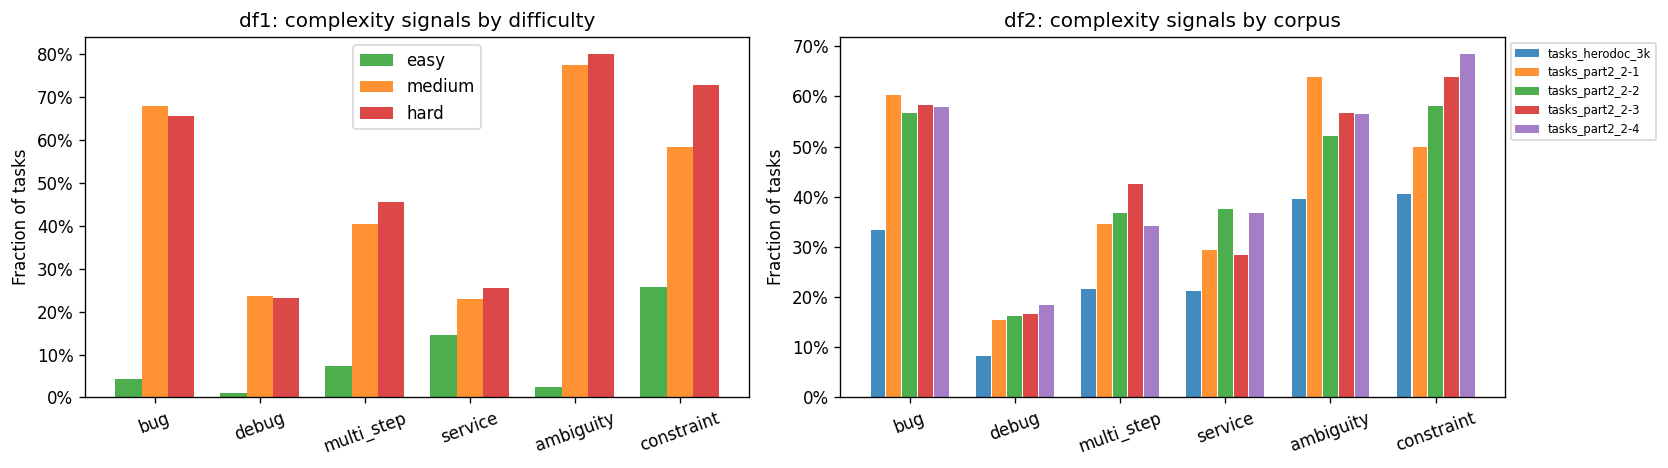

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# df1: signals by difficulty
sig_means_1 = df1.groupby('difficulty')[bool_cols].mean().reindex(diff_order)
x = np.arange(len(bool_cols))
w = 0.25
for i, diff in enumerate(diff_order):
    axes[0].bar(x + i*w, sig_means_1.loc[diff], width=w,
                label=diff, color=colors_diff[diff], alpha=0.85)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels([c.replace('has_', '') for c in bool_cols], rotation=20)
axes[0].set_ylabel('Fraction of tasks')
axes[0].set_title('df1: complexity signals by difficulty')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# df2: signals by corpus
corpus_order = sorted(df2['gt_corpus'].unique())
corpus_colors = plt.cm.tab10.colors
sig_means_2 = df2.groupby('gt_corpus')[bool_cols].mean()
for i, corpus in enumerate(corpus_order):
    axes[1].bar(x + i * (0.15), sig_means_2.loc[corpus], width=0.14,
                label=corpus, color=corpus_colors[i], alpha=0.85)
axes[1].set_xticks(x + 0.30)
axes[1].set_xticklabels([c.replace('has_', '') for c in bool_cols], rotation=20)
axes[1].set_ylabel('Fraction of tasks')
axes[1].set_title('df2: complexity signals by corpus')
axes[1].legend(fontsize=7, bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### Complexity signals vs pass rate (df1)

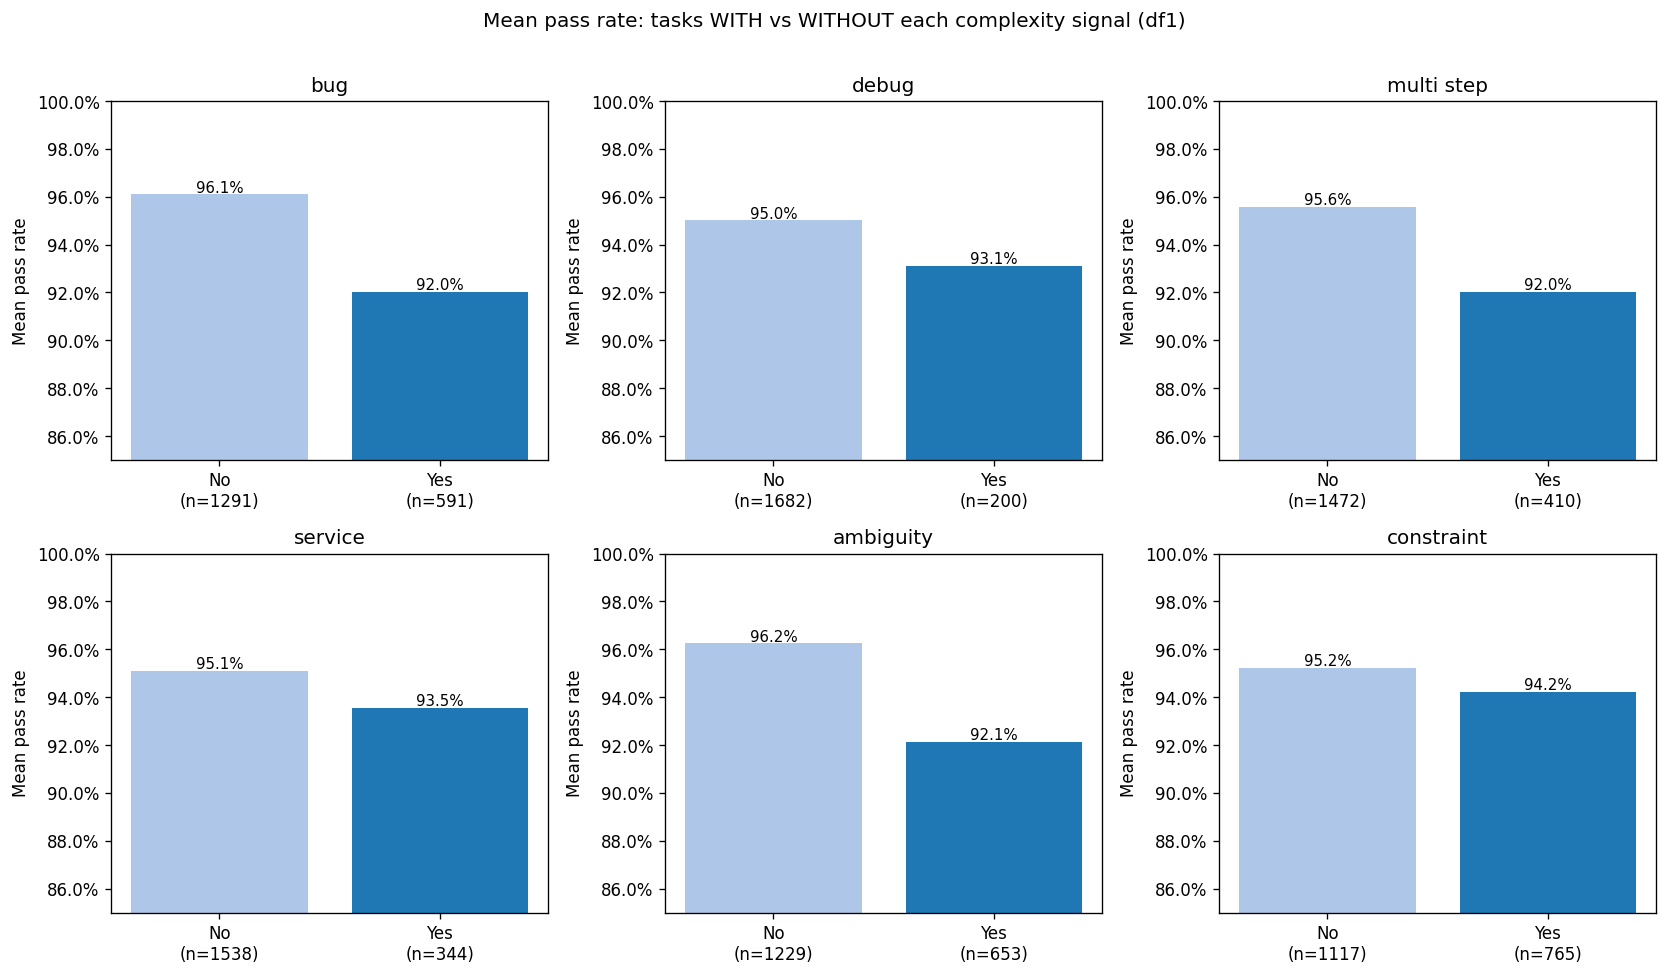

In [47]:
df1_eval2 = df1[df1['pass_rate'].notna()].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, bool_cols):
    grp = df1_eval2.groupby(col)['pass_rate'].mean()
    labels = {False: f'No\n(n={df1_eval2[col].eq(False).sum()})',
              True:  f'Yes\n(n={df1_eval2[col].eq(True).sum()})'}
    ax.bar([labels[False], labels[True]], [grp.get(False, 0), grp.get(True, 0)],
           color=['#aec7e8', '#1f77b4'])
    ax.set_title(col.replace('has_', '').replace('_', ' '))
    ax.set_ylabel('Mean pass rate')
    ax.set_ylim(0.85, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for i, (k, v) in enumerate([(False, grp.get(False, 0)), (True, grp.get(True, 0))]):
        ax.text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('Mean pass rate: tasks WITH vs WITHOUT each complexity signal (df1)', y=1.01)
plt.tight_layout()
plt.show()

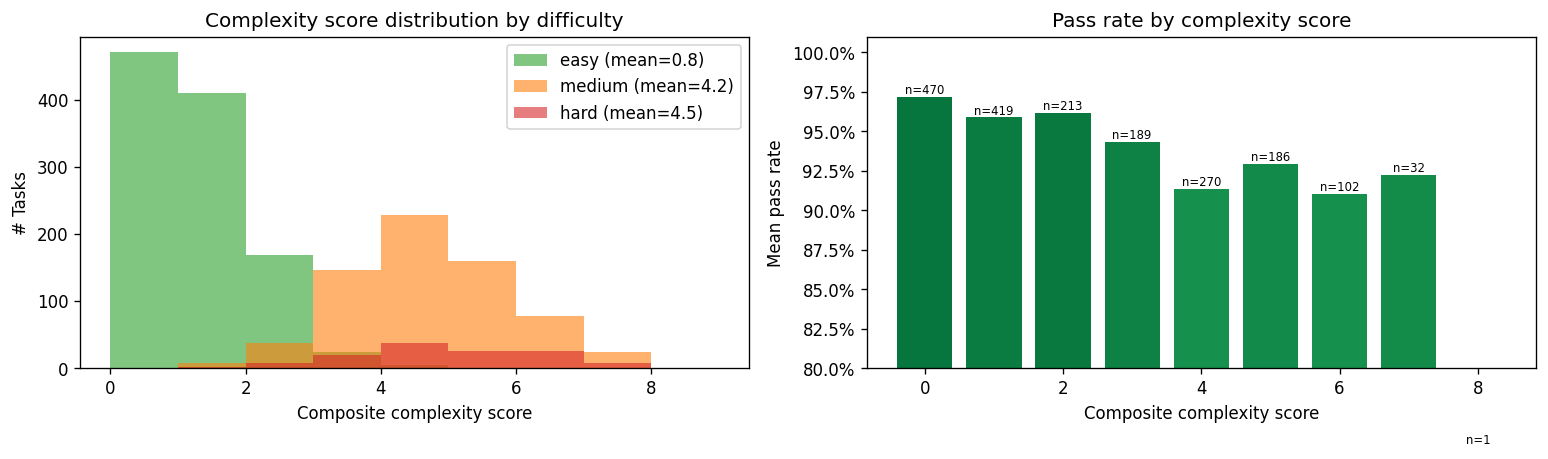

In [48]:
# Composite complexity score = sum of all bool signals + normalized desc_len
df1_eval2['complexity_score'] = (
    df1_eval2[bool_cols].sum(axis=1)
    + (df1_eval2['n_questions'] > 0).astype(int)
    + (df1_eval2['n_test_fns'] > df1_eval2['n_test_fns'].median()).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution by difficulty
for diff in diff_order:
    sub = df1_eval2[df1_eval2['difficulty'] == diff]['complexity_score']
    axes[0].hist(sub, bins=range(0, 10), alpha=0.6,
                 label=f'{diff} (mean={sub.mean():.1f})', color=colors_diff[diff])
axes[0].set_xlabel('Composite complexity score')
axes[0].set_ylabel('# Tasks')
axes[0].set_title('Complexity score distribution by difficulty')
axes[0].legend()

# Score vs pass rate
sc_pass = df1_eval2.groupby('complexity_score')['pass_rate'].agg(['mean', 'count'])
axes[1].bar(sc_pass.index, sc_pass['mean'],
            color=[plt.cm.RdYlGn(v) for v in sc_pass['mean']])
for x, (mean, cnt) in sc_pass.iterrows():
    axes[1].text(x, mean + 0.002, f'n={int(cnt)}', ha='center', fontsize=7)
axes[1].set_xlabel('Composite complexity score')
axes[1].set_ylabel('Mean pass rate')
axes[1].set_title('Pass rate by complexity score')
axes[1].set_ylim(0.8, 1.01)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### Cross-dataset complexity comparison (df1 vs df2)

,has_bug,has_debug,has_multi_step,has_service,has_ambiguity,has_constraint,n_sentences,n_questions,desc_len
dataset,,,,,,,,,
df1 (8192),0.314,0.106,0.218,0.183,0.347,0.406,8.141,0.238,481.873
df2 (4.6opus),0.445,0.120,0.286,0.264,0.474,0.489,8.811,0.329,552.038


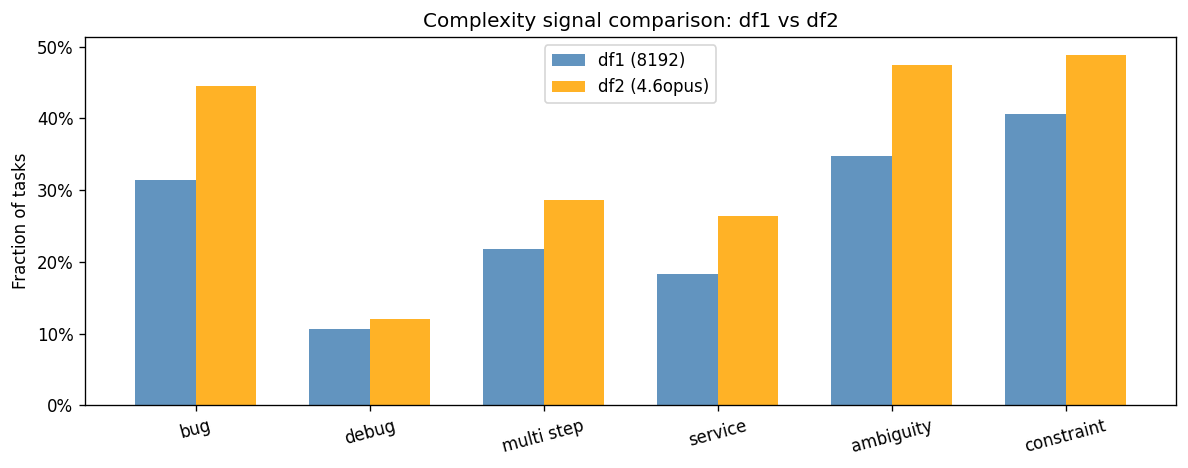


Key takeaways:
  bug                 : df2 is 13% higher (31% vs 44%)
  multi_step          : df2 is 7% higher (22% vs 29%)
  service             : df2 is 8% higher (18% vs 26%)
  ambiguity           : df2 is 13% higher (35% vs 47%)
  constraint          : df2 is 8% higher (41% vs 49%)


In [49]:
df1['dataset'] = 'df1 (8192)'
df2['dataset'] = 'df2 (4.6opus)'
combined = pd.concat([df1[['dataset', 'desc_len'] + bool_cols + ['n_sentences', 'n_questions']],
                      df2[['dataset', 'desc_len'] + bool_cols + ['n_sentences', 'n_questions']]], ignore_index=True)

compare = combined.groupby('dataset')[bool_cols + ['n_sentences', 'n_questions', 'desc_len']].mean().round(3)
display(compare)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bool_cols))
w = 0.35
for i, (ds, color) in enumerate([('df1 (8192)', 'steelblue'), ('df2 (4.6opus)', 'orange')]):
    vals = compare.loc[ds, bool_cols]
    ax.bar(x + i * w, vals, width=w, label=ds, color=color, alpha=0.85)

ax.set_xticks(x + w / 2)
ax.set_xticklabels([c.replace('has_', '').replace('_', ' ') for c in bool_cols], rotation=15)
ax.set_ylabel('Fraction of tasks')
ax.set_title('Complexity signal comparison: df1 vs df2')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

print("\nKey takeaways:")
for col in bool_cols:
    d1v = compare.loc['df1 (8192)', col]
    d2v = compare.loc['df2 (4.6opus)', col]
    delta = d2v - d1v
    direction = "higher" if delta > 0 else "lower"
    if abs(delta) > 0.05:
        print(f"  {col.replace('has_',''):20s}: df2 is {abs(delta):.0%} {direction} ({d1v:.0%} vs {d2v:.0%})")

---
## Part 4 — Category distribution (full `harbor_tasks_8192` corpus)

All 3,310 tasks × 61 categories, with difficulty and eval pass rate.

In [ ]:
import json as _json

# Load full corpus metadata (category + difficulty + eval pass rate for every task)
with open('/tmp/corpus_meta.json') as f:
    _rows = _json.load(f)

df_corpus = pd.DataFrame(_rows)

# Category count sorted descending
cat_counts = df_corpus['category'].value_counts()

print(f"Full corpus: {len(df_corpus):,} tasks, {df_corpus['category'].nunique()} unique categories")
print(f"\nDifficulty split:")
print(df_corpus['difficulty'].value_counts())
print(f"\nTasks with eval data: {df_corpus['n_trials'].gt(0).sum():,}")

In [ ]:
# Full category count bar chart (all 61, sorted)
fig, ax = plt.subplots(figsize=(10, 16))

cats_sorted = cat_counts.sort_values()
ax.barh(cats_sorted.index, cats_sorted.values, color='steelblue', height=0.75)
ax.axvline(cat_counts.mean(), color='orange', linestyle='--', linewidth=1,
           label=f'mean = {cat_counts.mean():.0f}')
ax.set_xlabel('# Tasks')
ax.set_title('Category distribution — harbor_tasks_8192 (all 61 categories)')
ax.legend()
for i, (cat, n) in enumerate(cats_sorted.items()):
    ax.text(n + 0.5, i, str(n), va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

In [ ]:
# Stacked bar: difficulty mix per category, sorted by total count
diff_order_c = ['easy', 'medium', 'hard']
diff_colors_c = {'easy': '#2ca02c', 'medium': '#ff7f0e', 'hard': '#d62728'}

diff_by_cat = (df_corpus.groupby(['category', 'difficulty'])
               .size().unstack(fill_value=0)
               .reindex(columns=diff_order_c, fill_value=0))
diff_by_cat['total'] = diff_by_cat.sum(axis=1)
diff_by_cat = diff_by_cat.sort_values('total')

fig, ax = plt.subplots(figsize=(10, 16))
left = pd.Series(0, index=diff_by_cat.index)
for diff in diff_order_c:
    ax.barh(diff_by_cat.index, diff_by_cat[diff], left=left,
            color=diff_colors_c[diff], label=diff, height=0.75)
    left += diff_by_cat[diff]

ax.set_xlabel('# Tasks')
ax.set_title('Category × difficulty (stacked)')
ax.legend(title='difficulty', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# % hard per category — which categories skew hardest
diff_by_cat['pct_hard']   = diff_by_cat['hard']   / diff_by_cat['total']
diff_by_cat['pct_medium'] = diff_by_cat['medium']  / diff_by_cat['total']
diff_by_cat['pct_easy']   = diff_by_cat['easy']    / diff_by_cat['total']

top_hard = diff_by_cat['pct_hard'].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(top_hard)), top_hard.values, color='#d62728')
ax.set_xticks(range(len(top_hard)))
ax.set_xticklabels(top_hard.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% Hard tasks')
ax.set_title('Top 20 categories by fraction of hard tasks')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate(top_hard.values):
    ax.text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

In [ ]:
# Pass rate per category (tasks with eval data only)
df_eval_cat = df_corpus[df_corpus['n_trials'] > 0].copy()

cat_pass = df_eval_cat.groupby('category').agg(
    n_eval=('task_dir', 'count'),
    pass_rate=('pass_rate', 'mean'),
    n_pass=('n_pass', 'sum'),
    n_trials=('n_trials', 'sum'),
).sort_values('pass_rate')

fig, ax = plt.subplots(figsize=(10, 16))
colors_pass = ['#d62728' if v < 0.88 else '#ff7f0e' if v < 0.94 else '#2ca02c'
               for v in cat_pass['pass_rate']]
ax.barh(cat_pass.index, cat_pass['pass_rate'], color=colors_pass, height=0.75)
ax.axvline(df_eval_cat['pass_rate'].mean(), color='black', linestyle='--',
           linewidth=0.9, label=f'overall mean={df_eval_cat["pass_rate"].mean():.1%}')
ax.set_xlabel('Mean pass rate')
ax.set_title('Category pass rate (eval tasks only, sorted lowest→highest)')
ax.set_xlim(0.7, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
for i, (cat, row) in enumerate(cat_pass.iterrows()):
    ax.text(row['pass_rate'] + 0.003, i, f'{row["pass_rate"]:.1%}  (n={int(row["n_eval"])})',
            va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Scatter: task count vs pass rate, bubble size = % hard, colored by broad group
def broad_group(cat):
    c = cat.lower()
    if any(k in c for k in ['git', 'version', 'changelog', 'diff', 'submodule']): return 'version_control'
    if any(k in c for k in ['web', 'http', 'server', 'api', 'curl']): return 'web_services'
    if any(k in c for k in ['file', 'directory', 'symlink', 'compress', 'backup', 'checksum', 'disk', 'find']): return 'filesystem'
    if any(k in c for k in ['sql', 'database', 'sqlite', 'migration']): return 'database'
    if any(k in c for k in ['python', 'pip', 'venv', 'package']): return 'python_env'
    if any(k in c for k in ['network', 'firewall', 'dns', 'ssh', 'remote', 'sync']): return 'networking'
    if any(k in c for k in ['data', 'csv', 'json', 'yaml', 'toml', 'ini', 'log', 'awk', 'sed', 'text', 'sort', 'cut', 'regex']): return 'data_text'
    if any(k in c for k in ['service', 'daemon', 'systemd', 'container', 'docker', 'cron', 'scheduled', 'process']): return 'services_infra'
    if any(k in c for k in ['security', 'gpg', 'certificate', 'exploit', 'permission', 'user']): return 'security_auth'
    if any(k in c for k in ['performance', 'optim', 'monitoring', 'diagnostic', 'distributed']): return 'perf_monitoring'
    return 'other'

cat_summary = df_eval_cat.groupby('category').agg(
    n=('task_dir', 'count'),
    pass_rate=('pass_rate', 'mean'),
).join(diff_by_cat[['pct_hard', 'total']])
cat_summary['group'] = cat_summary.index.map(broad_group)

group_colors = {
    'version_control': '#1f77b4', 'web_services': '#ff7f0e', 'filesystem': '#2ca02c',
    'database': '#9467bd', 'python_env': '#8c564b', 'networking': '#e377c2',
    'data_text': '#7f7f7f', 'services_infra': '#bcbd22', 'security_auth': '#d62728',
    'perf_monitoring': '#17becf', 'other': '#aec7e8',
}

fig, ax = plt.subplots(figsize=(11, 7))
for group, grp in cat_summary.groupby('group'):
    ax.scatter(grp['n'], grp['pass_rate'],
               s=grp['pct_hard'] * 1200 + 40,
               color=group_colors.get(group, 'grey'),
               alpha=0.75, label=group, edgecolors='white', linewidths=0.5)
    for cat, row in grp.iterrows():
        ax.annotate(cat, (row['n'], row['pass_rate']),
                    fontsize=6.5, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

ax.set_xlabel('# Tasks in corpus')
ax.set_ylabel('Mean pass rate')
ax.set_title('Category: task count vs pass rate\n(bubble size = % hard tasks)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='group', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Full summary table: all 61 categories
cat_full = df_corpus.groupby('category').agg(
    total=('task_dir', 'count'),
    easy=('difficulty', lambda x: (x == 'easy').sum()),
    medium=('difficulty', lambda x: (x == 'medium').sum()),
    hard=('difficulty', lambda x: (x == 'hard').sum()),
).join(
    df_eval_cat.groupby('category').agg(
        n_eval=('task_dir', 'count'),
        pass_rate=('pass_rate', 'mean'),
    ), how='left'
)
cat_full['pct_hard']   = (cat_full['hard']   / cat_full['total']).round(2)
cat_full['pass_rate']  = cat_full['pass_rate'].round(3)
cat_full['group']      = cat_full.index.map(broad_group)
cat_full = cat_full.sort_values(['group', 'total'], ascending=[True, False])

display(cat_full[['group', 'total', 'easy', 'medium', 'hard', 'pct_hard', 'n_eval', 'pass_rate']])

---
## Part 5 — Context length analysis

Measured as characters and estimated tokens (chars / 4) across system prompt, user turn, and total prompt. Covers both training parquets and the full `harbor_tasks_8192` instruction files.

In [ ]:
# Recompute context length columns (idempotent if re-run)
for df, label in [(df1, 'df1'), (df2, 'df2')]:
    df['sys_chars']   = df['prompt'].apply(lambda p: len(str(p[0]['content'])))
    df['user_chars']  = df['prompt'].apply(lambda p: len(str(p[1]['content'])))
    df['total_chars'] = df['sys_chars'] + df['user_chars']
    df['est_tokens']  = (df['total_chars'] / 4).round(0).astype(int)

print("System prompt length is fixed at 1,234 chars for all rows in both datasets.")
print()
for label, df in [('df1 (8192)', df1), ('df2 (4.6opus)', df2)]:
    print(f"=== {label} ===")
    print(df[['sys_chars','user_chars','total_chars','est_tokens']].describe().round(1))
    print()

In [ ]:
# Overlapping histogram: user turn token length, df1 vs df2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins_tok = range(80, 820, 20)

for ax, col, title in [
    (axes[0], 'user_chars', 'User turn length (chars)'),
    (axes[1], 'est_tokens', 'Total prompt length (est. tokens)'),
]:
    bins = range(0, int(max(df1[col].max(), df2[col].max())) + 50, 
                 20 if col == 'est_tokens' else 80)
    ax.hist(df1[col], bins=bins, alpha=0.6, color='steelblue',
            label=f'df1 (8192)   mean={df1[col].mean():.0f}')
    ax.hist(df2[col], bins=bins, alpha=0.6, color='orange',
            label=f'df2 (4.6opus) mean={df2[col].mean():.0f}')
    ax.axvline(df1[col].median(), color='steelblue', linestyle='--', linewidth=1)
    ax.axvline(df2[col].median(), color='orange',    linestyle='--', linewidth=1)
    ax.set_xlabel(title)
    ax.set_ylabel('# Tasks')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# df1: token length by difficulty
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot by difficulty
data_by_diff = [df1[df1['difficulty'] == d]['est_tokens'].values for d in diff_order]
bp = axes[0].boxplot(data_by_diff, labels=diff_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch, diff in zip(bp['boxes'], diff_order):
    patch.set_facecolor(colors_diff[diff])
    patch.set_alpha(0.7)
axes[0].set_ylabel('Est. tokens')
axes[0].set_title('df1: prompt token length by difficulty')

# Mean token length per category (top 20 longest)
cat_tok = df1.groupby('category')['est_tokens'].mean().sort_values(ascending=False).head(20)
axes[1].barh(cat_tok.index[::-1], cat_tok.values[::-1], color='steelblue')
axes[1].axvline(df1['est_tokens'].mean(), color='orange', linestyle='--', linewidth=1,
                label=f'overall mean={df1["est_tokens"].mean():.0f}')
axes[1].set_xlabel('Mean est. tokens')
axes[1].set_title('Top 20 categories by mean prompt length (df1)')
axes[1].legend(fontsize=8)
for i, v in enumerate(cat_tok.values[::-1]):
    axes[1].text(v + 1, i, f'{v:.0f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

In [ ]:
# df2: token length by sub-corpus
fig, ax = plt.subplots(figsize=(9, 3.5))
corpus_order_2 = df2.groupby('gt_corpus')['est_tokens'].mean().sort_values().index
data_by_corpus = [df2[df2['gt_corpus'] == c]['est_tokens'].values for c in corpus_order_2]
bp = ax.boxplot(data_by_corpus, labels=corpus_order_2, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], plt.cm.tab10.colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Est. tokens')
ax.set_title('df2: prompt token length by sub-corpus')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Token length vs pass rate scatter (df1, eval tasks only)
df1_ev = df1[df1['pass_rate'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter colored by difficulty
for diff in diff_order:
    sub = df1_ev[df1_ev['difficulty'] == diff]
    axes[0].scatter(sub['est_tokens'], sub['pass_rate'],
                    alpha=0.25, s=10, color=colors_diff[diff], label=diff)
# Rolling mean
sorted_ev = df1_ev.sort_values('est_tokens')
rolling_pr = sorted_ev.set_index('est_tokens')['pass_rate'].rolling(80, min_periods=20).mean()
axes[0].plot(rolling_pr.index, rolling_pr.values, color='black', linewidth=1.5, label='rolling mean')
axes[0].set_xlabel('Est. tokens')
axes[0].set_ylabel('Pass rate')
axes[0].set_title(f'Token length vs pass rate  (r={df1_ev["est_tokens"].corr(df1_ev["pass_rate"]):.3f})')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(fontsize=8)

# Binned mean pass rate by token quartile
df1_ev['token_bin'] = pd.qcut(df1_ev['est_tokens'], q=10, duplicates='drop')
bin_pass = df1_ev.groupby('token_bin', observed=True)['pass_rate'].agg(['mean','count'])
axes[1].bar(range(len(bin_pass)), bin_pass['mean'],
            color=[plt.cm.RdYlGn(v) for v in bin_pass['mean']])
axes[1].set_xticks(range(len(bin_pass)))
axes[1].set_xticklabels([str(b) for b in bin_pass.index], rotation=45, ha='right', fontsize=7)
for i, (mean, cnt) in enumerate(zip(bin_pass['mean'], bin_pass['count'])):
    axes[1].text(i, mean + 0.002, f'n={int(cnt)}', ha='center', fontsize=7)
axes[1].set_ylabel('Mean pass rate')
axes[1].set_title('Pass rate by token-length decile')
axes[1].set_ylim(0.88, 1.0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

In [ ]:
# Full corpus: instruction.md length distribution (all 3310 tasks)
instr_lengths = []
for p in sorted(Path('../harbor_tasks_8192').glob('*/instruction.md')):
    instr_lengths.append({'task_dir': p.parent.name, 'instr_chars': len(p.read_text())})
df_instr = pd.DataFrame(instr_lengths)
df_instr['instr_tokens'] = (df_instr['instr_chars'] / 4).round(0).astype(int)
df_instr = df_instr.merge(
    pd.DataFrame([{'task_dir': p.parent.name,
                   'difficulty': re.search(r'difficulty\s*=\s*"([^"]+)"', p.read_text()) and
                                 re.search(r'difficulty\s*=\s*"([^"]+)"', p.read_text()).group(1)}
                  for p in Path('../harbor_tasks_8192').glob('*/task.toml')]),
    on='task_dir', how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_instr['instr_tokens'], bins=40, color='steelblue', edgecolor='white')
for q, ls in [(0.5,'--'),(0.9,':')]:
    v = df_instr['instr_tokens'].quantile(q)
    axes[0].axvline(v, color='orange', linestyle=ls, linewidth=1.2,
                    label=f'p{int(q*100)}={v:.0f} tok')
axes[0].set_xlabel('Est. tokens (instruction.md)')
axes[0].set_ylabel('# Tasks')
axes[0].set_title('Full corpus: instruction length (3,310 tasks)')
axes[0].legend()

data_instr = [df_instr[df_instr['difficulty']==d]['instr_tokens'].values for d in diff_order]
bp = axes[1].boxplot(data_instr, labels=diff_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch, diff in zip(bp['boxes'], diff_order):
    patch.set_facecolor(colors_diff[diff]); patch.set_alpha(0.7)
axes[1].set_ylabel('Est. tokens')
axes[1].set_title('Instruction length by difficulty (full corpus)')

plt.tight_layout()
plt.show()

print("Instruction token percentiles (full corpus):")
print(df_instr['instr_tokens'].quantile([.1,.25,.5,.75,.9,.95,.99]).round(0).astype(int).to_dict())